In [26]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
%matplotlib inline

import tensorflow as tf

C:\Users\ATISHAY SG\AppData\Local\Temp\ipykernel_18800\3405315510.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


In [27]:
tf.__version__

'2.14.0'

[ 0  1  2  3  4  5  6  7  8  9 10] [ 1.28930158  3.62524449  4.66295115  7.39548872  8.96225045 10.15510713
 13.04506381 14.96825172 16.47470458 19.56264507 21.0494154 ]


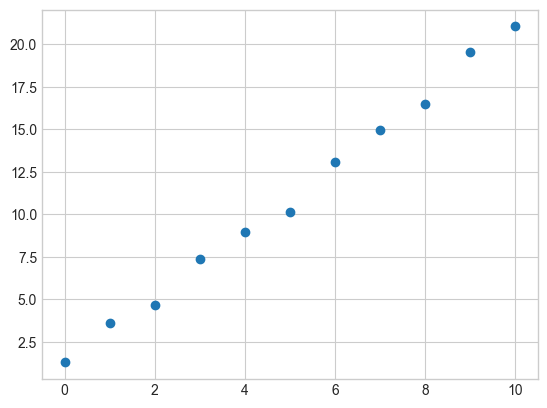

In [28]:
x_train = np.arange(11)
y_train = 2 * x_train + 1 + np.random.normal(0, 0.5, len(x_train))
print(x_train, y_train)
plt.scatter(x_train, y_train)

Initialize the weights as a single matrix.   
initializer


In [34]:
w1 = tf.Variable(0.01 * np.random.normal())
w2 = tf.Variable(0.01 * np.random.normal())


---

Loss Function

---

In [35]:
def mse_loss(y, yhat):
    return tf.reduce_mean(tf.square(y - yhat))

Gradient and loss function for one step

In [39]:
# def onestep(x, y, learning_rate=0.01):
#     with tf.GradientTape(persistent=True) as g:
#         yhat = w1*x + w2  # forward pass later rewrite this as Wx_B
#         loss = mse_loss(y, yhat) # Calculate loss

#     # Calculate gradients
#     w1_grad, w2_grad = g.gradient(loss, w1), g.gradient(loss, w2)
#     print('w1_grad:', w1_grad)

#     # Update weights
#     w1.assign_sub(w1_grad * learning_rate)
#     w2.assign_sub(w2_grad * learning_rate)

In [44]:
def onestep(x, y, learning_rate=0.01):
    with tf.GradientTape(persistent=True) as g:
        z = w1*x + w2  # forward pass later rewrite this as Wx_B
        a = np.tanh(z)

        z2 = w1 * a + w2

        loss = mse_loss(y, a)
    # Calculate gradients
    gradL_w = g.gradient(z, w1)
    print('w1_grad:', gradL_w)

    # Update weights
    w1.assign_sub(gradL_w * learning_rate)
    w2.assign_sub(gradL_w * learning_rate)

---

Training loop

---

In [45]:
# batch_size = 1
niters = 10

for iter in range(niters):
    onestep(x_train, y_train)

w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)
w1_grad: tf.Tensor(55.0, shape=(), dtype=float32)


In [47]:
print(w1.numpy(), w2.numpy())

-8.919989 -6.1875396
